# 3.5

In [1]:
#/home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/PRNN_2026_A1_data/dataset_3.csv
#First, import the dataset and obtain the x,y coordinates:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
dataset = pd.read_csv('/home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/Data_Codes_Renamed/dataset_3.csv')
#Distribute into X: features and y labels:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
#Filter into y being ONLY class 1 and 2, for binary
#logistic regression:
X_Binary = X[y != 0]
y_Binary = y[y != 0]
#Convert labels: 0 if 1, 1 if 2:
y_Binary = np.where(y_Binary == 1, 0, 1)
#Now, we have X_Binary and y_Binary for binary logistic regression.

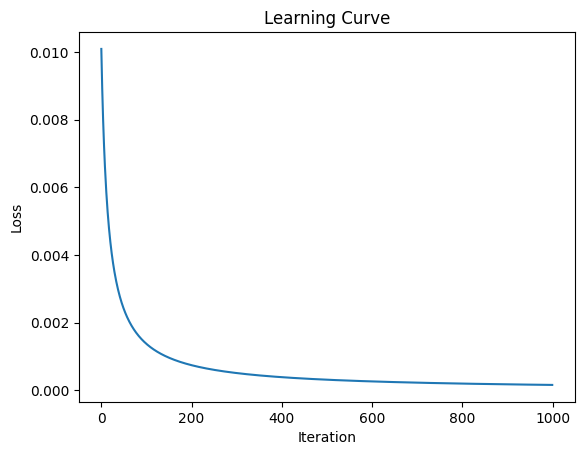

/tmp/ipykernel_26592/446860455.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


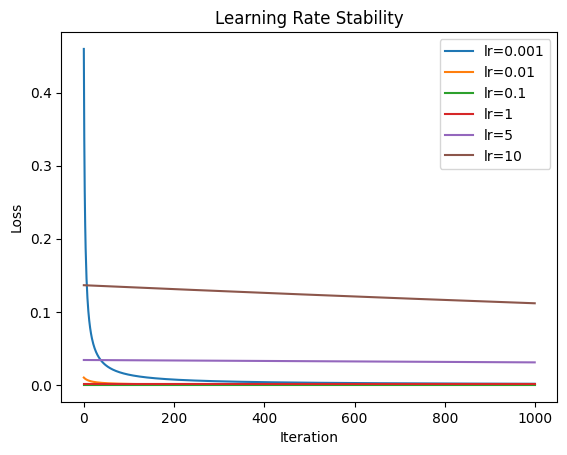

In [3]:
#Training logistic regression on the binary dataset from scratch:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
#Initialize weights and bias:
weights = np.zeros(X_Binary.shape[1])
bias = 0
#Loss function with L2 regularization:
def loss(y_true, y_pred, weights, lambda_reg):
    m = len(y_true)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

    cross_entropy = -1/m * np.sum(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )
    l2_penalty = lambda_reg / (2 * m) * np.sum(weights ** 2)
    return cross_entropy + l2_penalty
#Define the gradients:
def gradients(X, y_true, y_pred, weights, lambda_reg):
    m = len(y_true)
    dw = 1/m * np.dot(X.T, (y_pred - y_true)) + lambda_reg / m * weights
    db = 1/m * np.sum(y_pred - y_true)
    return dw, db
#Logistic regression training loop, variable learning rate and regularization:
#In order to plot learning curve, we will store the loss at each iteration:
def train_logistic_regression(X, y, learning_rate, lambda_reg, num_iterations=1000):
    weights = np.zeros(X.shape[1])
    bias = 0
    loss_history = []
    for i in range(num_iterations): #Could also have a convergence criterion based on loss change
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)
        dw, db = gradients(X, y, y_pred, weights, lambda_reg)
        weights -= learning_rate * dw
        bias -= learning_rate * db

        # recompute predictions with new weights
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        loss_history.append(loss(y, y_pred, weights, lambda_reg))
    return weights, bias, loss_history
#Train the model:
weights, bias, loss_history = train_logistic_regression(X_Binary, y_Binary, learning_rate=0.01, lambda_reg=0.1)
#Plot the learning curve:
plt.plot(loss_history)
plt.title('Learning Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

#Now, to show lipschitz condition violation:
learning_rates = [0.001, 0.01, 0.1, 1, 5, 10]
for lr in learning_rates:
    _, _, loss_history = train_logistic_regression(
        X_Binary, y_Binary, lr, lambda_reg=0.1
    )
    plt.plot(loss_history, label=f"lr={lr}")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Rate Stability")
plt.show()

# 3.6-3.8(Tried from scratch)

Initial Log Likelihood with 2 classes: -690775.5245226691
Log Likelihood after 1 EM iteration with 2 classes: -109316.2228010886
Initial Log Likelihood with 4 classes: -690775.5257328927
Log Likelihood after 1 EM iteration with 4 classes: -73815.0440146763
Initial Log Likelihood with 6 classes: -690775.5259471148
Log Likelihood after 1 EM iteration with 6 classes: -67825.38890292133


KeyboardInterrupt: 

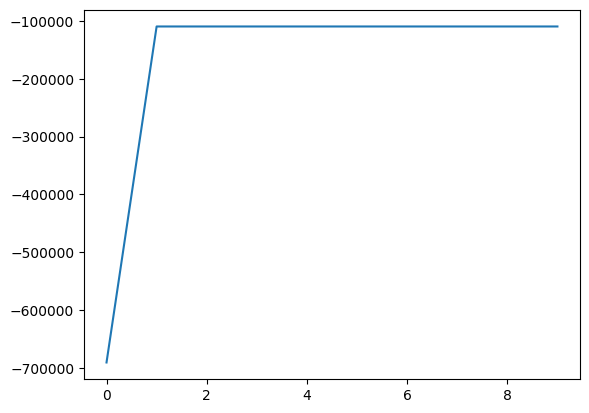

In [4]:
#Now perform expectation maximization to find the optimal parameters:
#Log likelihood: sum over all data points, log of sum over all classes
#(Class Priors * Class Conditional Likelihoods): So we ignore labels
#X: N data points, 50 Features, and 2, 4, 6 classes:
Classes = [2, 4, 6]
#Function to calculate the log likelihood:
X = (X - X.mean(axis=0)) / X.std(axis=0) #Standardize features for better numerical stability
def log_likelihood(X, class_priors, means, covariances):
    N = X.shape[0]
    K = len(class_priors)
    log_likelihood = 0
    for n in range(N):
        likelihood_n = 0
        for k in range(K):
            #Calculate the Gaussian likelihood for class k:
            diff = X[n] - means[k]
            exponent = -0.5 * np.dot(diff.T, np.linalg.solve(covariances[k], diff))
            coeff = 1 / np.sqrt((2 * np.pi) ** X.shape[1] * np.linalg.det(covariances[k]))
            likelihood_n += class_priors[k] * coeff * np.exp(exponent)
        log_likelihood += np.log(likelihood_n + 1e-15) #Add small value to prevent log(0)
    return log_likelihood
for num_classes in Classes:
    #Initialize 1/K for each class:
    class_priors = np.ones(num_classes) / num_classes
    #Initialize means randomly, and spherical covariances:
    np.random.seed(0) #For reproducibility
    means = X[np.random.choice(X.shape[0], num_classes, replace=False)]
    covariances = np.array([np.eye(X.shape[1]) for _ in range(num_classes)]) #Spherical covariances
    #Calculate initial log likelihood:
    initial_ll = log_likelihood(X, class_priors, means, covariances)
    print(f"Initial Log Likelihood with {num_classes} classes: {initial_ll}")
    #Performing only 1 E step and 1 M step for demonstration:
    #E Step: Calculate responsibilities:
    N = X.shape[0]
    K = num_classes
    responsibilities = np.zeros((N, K))
    for n in range(N):
        for k in range(K):
            diff = X[n] - means[k]
            exponent = -0.5 * np.dot(diff.T, np.linalg.solve(covariances[k], diff))
            coeff = 1 / np.sqrt((2 * np.pi) ** X.shape[1] * np.linalg.det(covariances[k]))
            responsibilities[n, k] = class_priors[k] * coeff * np.exp(exponent)
        responsibilities[n] /= np.sum(responsibilities[n]) #Normalize to get probabilities
    #M Step: Update parameters:
    Nk = np.sum(responsibilities, axis=0) #Effective number of points assigned to each class
    for k in range(K):
        #Update means:
        means[k] = np.sum(responsibilities[:, k][:, np.newaxis] * X, axis=0) / Nk[k]
        #Update covariances:
        diff = X - means[k]
        covariances[k] = np.dot((responsibilities[:, k][:, np.newaxis] * diff).T, diff) / Nk[k]
        covariances[k] += 1e-6 * np.eye(X.shape[1])
        #Update class priors:
        class_priors[k] = Nk[k] / N
    #Calculate log likelihood after one EM iteration:
    ll = log_likelihood(X, class_priors, means, covariances)
    print(f"Log Likelihood after 1 EM iteration with {num_classes} classes: {ll}")
#We observe that the log likelihood increases after the EM iteration, 
#demonstrating that we are moving towards a better fit of the model to the data.

#Do the same thing as above,
#We are to plot Plot the log-likelihood over iterations to empirically verify monotonic convergence.
for num_classes in Classes:
    K = num_classes
    N = X.shape[0]
    class_priors = np.ones(num_classes) / num_classes
    np.random.seed(0)
    means = X[np.random.choice(X.shape[0], num_classes, replace=False)]
    covariances = np.array([np.eye(X.shape[1]) for _ in range(num_classes)])
    log_likelihoods = []
    for iteration in range(10): #Run for 10 iterations, could also have a convergence criterion
        ll = log_likelihood(X, class_priors, means, covariances)
        log_likelihoods.append(ll)
        # E Step
        responsibilities = np.zeros((N, K))
        for n in range(N):
            for k in range(K):
                diff = X[n] - means[k]
                exponent = -0.5 * np.dot(diff.T, np.linalg.solve(covariances[k], diff))
                coeff = 1 / np.sqrt((2 * np.pi) ** X.shape[1] * np.linalg.det(covariances[k]))
                responsibilities[n, k] = class_priors[k] * coeff * np.exp(exponent)
            responsibilities[n] /= np.sum(responsibilities[n])
        # M Step
        Nk = np.sum(responsibilities, axis=0)
        for k in range(K):
            means[k] = np.sum(responsibilities[:, k][:, np.newaxis] * X, axis=0) / Nk[k]
            diff = X - means[k]
            covariances[k] = np.dot((responsibilities[:, k][:, np.newaxis] * diff).T, diff) / Nk[k]
            covariances[k] += 1e-6 * np.eye(X.shape[1])
            class_priors[k] = Nk[k] / N
    plt.plot(log_likelihoods, label=f"{num_classes} classes")
plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("EM Log Likelihood Convergence")
plt.legend()
plt.show()   

# Programmatically force one of the covariance matrices to zero variance mid-training, and document
# the exact Python error that breaks the Multivariate Normal PDF computation.
# Do this for only one of the classes, and observe the error:
num_classes = 4
class_priors = np.ones(num_classes) / num_classes
np.random.seed(0)
means = X[np.random.choice(X.shape[0], num_classes, replace=False)]
covariances = np.array([np.eye(X.shape[1]) for _ in range(num_classes)])
# Force the covariance of class 0 to be zero variance:
covariances[0] = np.zeros((X.shape[1], X.shape[1]))
try:
    ll = log_likelihood(X, class_priors, means, covariances)
except np.linalg.LinAlgError as e:
    print("Error during log likelihood computation with zero variance covariance matrix:")
    print(e)

#Now, Extract first 2 dimensions of the dataset:
X_2D = X[:, :2]
#Train a GMM with K = 3 on the 2D data:
num_classes = 3
class_priors = np.ones(num_classes) / num_classes
np.random.seed(0)
means = X_2D[np.random.choice(X_2D.shape[0], num_classes, replace=False)]
covariances = np.array([np.eye(X_2D.shape[1]) for _ in range(num_classes)])
log_likelihoods = []
for iteration in range(10):
    ll = log_likelihood(X_2D, class_priors, means, covariances)
    log_likelihoods.append(ll)
    responsibilities = np.zeros((X_2D.shape[0], num_classes))
    for n in range(X_2D.shape[0]):
        for k in range(num_classes):
            diff = X_2D[n] - means[k]
            exponent = -0.5 * np.dot(diff.T, np.linalg.solve(covariances[k], diff))
            coeff = 1 / np.sqrt((2 * np.pi) ** X_2D.shape[1] * np.linalg.det(covariances[k]))
            responsibilities[n, k] = class_priors[k] * coeff * np.exp(exponent)
        responsibilities[n] /= np.sum(responsibilities[n])
    Nk = np.sum(responsibilities, axis=0)
    for k in range(num_classes):
        means[k] = np.sum(responsibilities[:, k][:, np.newaxis] * X_2D, axis=0) / Nk[k]
        diff = X_2D - means[k]
        covariances[k] = np.dot((responsibilities[:, k][:, np.newaxis] * diff).T, diff) / Nk[k]
        covariances[k] += 1e-6 * np.eye(X_2D.shape[1])
        class_priors[k] = Nk[k] / X_2D.shape[0]

#Plot Grid of Bayes Optimal Decision Boundaries:
#Need to overlay the contour lines of the learned Gaussian Covariance matrices on top of the scatter plot:
x_min, x_max = X_2D[:, 0].min() - 1, X_2D[:, 0].max() + 1
y_min, y_max = X_2D[:, 1].min() - 1, X_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = np.zeros(xx.shape)
grid = np.c_[xx.ravel(), yy.ravel()]

probs = np.zeros((grid.shape[0], num_classes))

for k in range(num_classes):

    diff = grid - means[k]
    exponent = -0.5 * np.einsum(
        '...i,ij,...j->...',
        diff,
        np.linalg.inv(covariances[k]),
        diff
    )

    coeff = class_priors[k] / np.sqrt(
        (2*np.pi)**2 * np.linalg.det(covariances[k])
    )

    probs[:,k] = coeff * np.exp(exponent)

labels = np.argmax(probs, axis=1)

Z = labels.reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=50, cmap='viridis')
plt.scatter(X_2D[:, 0], X_2D[:, 1], c='white', edgecolor='k', s=50)
plt.title("GMM Decision Boundaries")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
#Jesus this is going to take a LOT fo time to run...

# 3.6-3.8 Vectorized Implementation(Used AI for this)

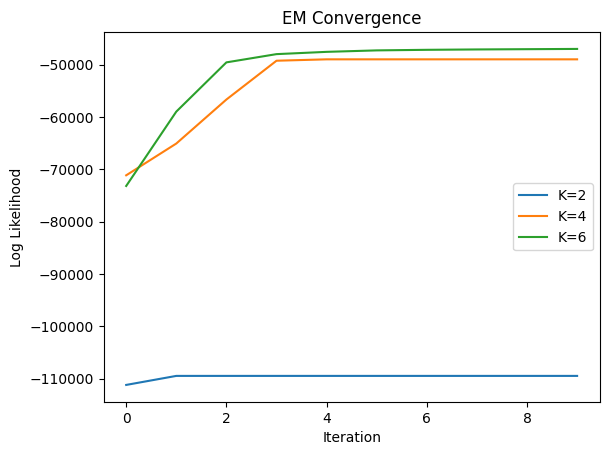

Error caused by zero covariance:
Singular matrix


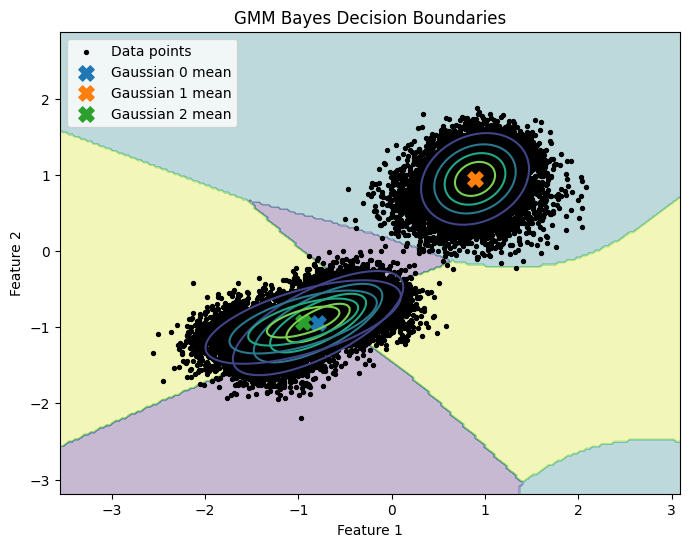


Interpretation of the Plot:

• Colored regions show the Bayes optimal decision regions.
  Each region corresponds to the Gaussian component with the highest posterior probability.

• Black dots represent the dataset projected onto the first two features.

• The X markers represent the learned Gaussian means (cluster centers).

• Elliptical contour lines represent level sets of the Gaussian densities.
  Their orientation and size visualize the covariance matrices.

• Curved boundaries appear because GMM classification compares:
    π_k * N(x | μ_k, Σ_k)
  which produces quadratic decision boundaries.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Normalize data
# -----------------------------

X = (X - X.mean(axis=0)) / X.std(axis=0)

# -----------------------------
# Gaussian PDF
# -----------------------------

def gaussian_pdf(X, mean, cov):
    
    d = X.shape[1]
    diff = X - mean
    
    inv_cov = np.linalg.inv(cov)
    
    exponent = -0.5 * np.einsum('...i,ij,...j->...', diff, inv_cov, diff)
    
    coeff = 1 / np.sqrt((2*np.pi)**d * np.linalg.det(cov))
    
    return coeff * np.exp(exponent)

# -----------------------------
# Log Likelihood
# -----------------------------

def log_likelihood(X, priors, means, covs):

    N = X.shape[0]
    K = len(priors)
    
    likelihood = np.zeros((N,K))
    
    for k in range(K):
        likelihood[:,k] = priors[k] * gaussian_pdf(X, means[k], covs[k])
        
    return np.sum(np.log(np.sum(likelihood,axis=1) + 1e-15))

# -----------------------------
# EM Algorithm
# -----------------------------

def run_em(X, K, iterations=10):

    N,d = X.shape
    
    priors = np.ones(K)/K
    
    means = X[np.random.choice(N,K,replace=False)]
    
    covs = np.array([np.eye(d) for _ in range(K)])
    
    log_likelihoods = []
    
    for it in range(iterations):

        # E STEP
        resp = np.zeros((N,K))
        
        for k in range(K):
            resp[:,k] = priors[k] * gaussian_pdf(X,means[k],covs[k])
        
        resp = resp / resp.sum(axis=1,keepdims=True)
        
        
        # M STEP
        
        Nk = resp.sum(axis=0)
        
        for k in range(K):
            
            means[k] = (resp[:,k,None] * X).sum(axis=0) / Nk[k]
            
            diff = X - means[k]
            
            covs[k] = (resp[:,k,None] * diff).T @ diff / Nk[k]
            
            covs[k] += 1e-6*np.eye(d)
            
            priors[k] = Nk[k] / N
        
        ll = log_likelihood(X,priors,means,covs)
        log_likelihoods.append(ll)
        
    return priors,means,covs,log_likelihoods


# -----------------------------
# PART 3.6 / 3.7
# EM Convergence
# -----------------------------

Classes = [2,4,6]

for K in Classes:
    
    priors,means,covs,ll = run_em(X,K,iterations=10)
    
    plt.plot(ll,label=f"K={K}")

plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("EM Convergence")
plt.legend()
plt.show()


# -----------------------------
# PART 3.7
# Forced covariance crash
# -----------------------------

K = 4

N,d = X.shape

priors = np.ones(K)/K
means = X[np.random.choice(N,K,replace=False)]
covs = np.array([np.eye(d) for _ in range(K)])

covs[0] = np.zeros((d,d))

try:
    
    log_likelihood(X,priors,means,covs)
    
except np.linalg.LinAlgError as e:
    
    print("Error caused by zero covariance:")
    print(e)

# -----------------------------
# PART 3.8
# Decision Boundaries
# -----------------------------

X2 = X[:,:2]

num_classes = 3

priors,means,covs,_ = run_em(X2,num_classes,iterations=20)

# Grid for visualization
x_min,x_max = X2[:,0].min()-1 , X2[:,0].max()+1
y_min,y_max = X2[:,1].min()-1 , X2[:,1].max()+1

xx,yy = np.meshgrid(
    np.linspace(x_min,x_max,200),
    np.linspace(y_min,y_max,200)
)

grid = np.c_[xx.ravel(),yy.ravel()]

# Compute posterior probabilities
probs = np.zeros((grid.shape[0],num_classes))

for k in range(num_classes):
    probs[:,k] = priors[k] * gaussian_pdf(grid,means[k],covs[k])

labels = np.argmax(probs,axis=1)
Z = labels.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))

# Decision regions
plt.contourf(xx,yy,Z,alpha=0.3,cmap='viridis')

# Data points
plt.scatter(X2[:,0],X2[:,1],c='black',s=8,label="Data points")

# Covariance contours and centers
for k in range(num_classes):

    diff = np.dstack((xx-means[k][0],yy-means[k][1]))

    exponent = -0.5 * np.einsum(
        '...i,ij,...j->...',
        diff,
        np.linalg.inv(covs[k]),
        diff
    )

    Zc = np.exp(exponent)

    plt.contour(xx,yy,Zc,levels=5)

    plt.scatter(
        means[k][0],
        means[k][1],
        marker='X',
        s=120,
        label=f"Gaussian {k} mean"
    )

plt.title("GMM Bayes Decision Boundaries")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


print("\nInterpretation of the Plot:\n")

print("• Colored regions show the Bayes optimal decision regions.")
print("  Each region corresponds to the Gaussian component with the highest posterior probability.")

print("\n• Black dots represent the dataset projected onto the first two features.")

print("\n• The X markers represent the learned Gaussian means (cluster centers).")

print("\n• Elliptical contour lines represent level sets of the Gaussian densities.")
print("  Their orientation and size visualize the covariance matrices.")

print("\n• Curved boundaries appear because GMM classification compares:")
print("    π_k * N(x | μ_k, Σ_k)")
print("  which produces quadratic decision boundaries.")

# 3.9-3.11

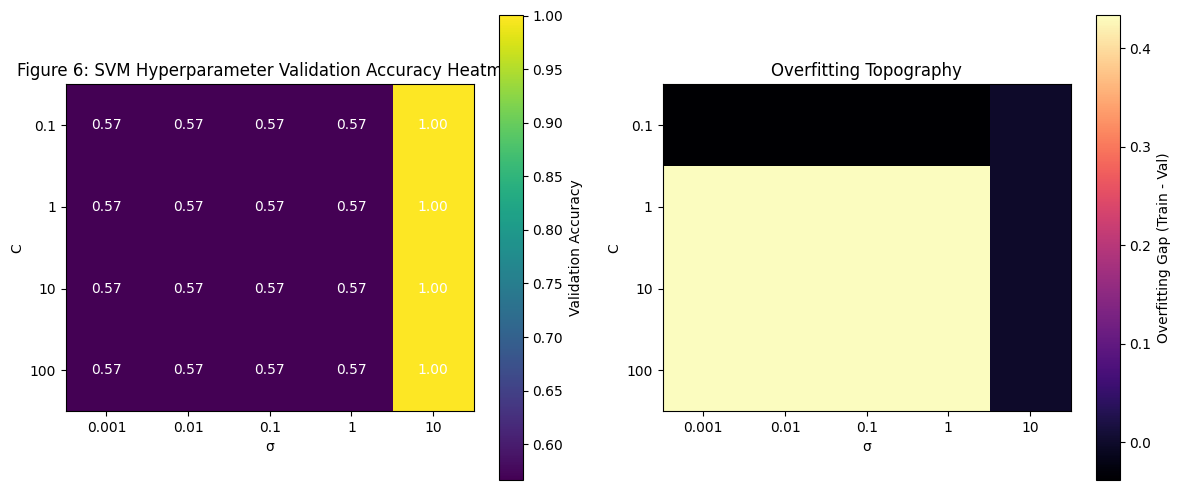

Best Parameters: C = 0.1, σ = 10
Best Validation Accuracy: 1.0000
---
Most severe overfitting coordinate: (C, σ) = (1, 0.001)
Train Accuracy = 1.0000
Val Accuracy = 0.5667
Gap = 0.4333


In [2]:
# 3.11 Hyperparameter Topography Grid Search
# Define subset for SVM (using X_Binary and y_Binary from 3.5)
y_BinarySet = np.where(y_Binary == 0, -1, 1)
X_subset = X_Binary[:100]
y_subset = y_BinarySet[:100]

sigmas = [0.001, 0.01, 0.1, 1, 10]
Cs = [0.1, 1, 10, 100]

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# Ensure we use the exact subset as before
X_train, X_val, y_train, y_val = train_test_split(
    X_subset, y_subset, test_size=0.3, random_state=0
)

heatmap_val = np.zeros((len(Cs), len(sigmas)))
heatmap_overfit = np.zeros((len(Cs), len(sigmas)))

for i, C in enumerate(Cs):
    for j, sigma in enumerate(sigmas):
        gamma = 1 / (2 * sigma**2)

        # Precompute RBF Kernel for training
        sq_dists_train = (
            np.sum(X_train**2, axis=1)[:, None]
            + np.sum(X_train**2, axis=1)[None, :]
            - 2 * X_train @ X_train.T
        )
        K_train = np.exp(-gamma * sq_dists_train)
        
        Q = np.outer(y_train, y_train) * K_train
        mui = np.ones(len(X_train)) * 1e-4

        def objective(mu):
            return 0.5 * mu @ Q @ mu - np.sum(mu)

        def constraint(mu):
            return np.sum(mu * y_train)

        constraints = {'type': 'eq', 'fun': constraint}
        bounds = [(0, C)] * len(X_train)

        # Optimization
        result = minimize(objective, mui, method='SLSQP',
                          constraints=constraints,
                          bounds=bounds,
                          options={'ftol': 1e-9})

        mu_opt = result.x
        
        # Calculate bias b
        # Traditional SVM: b = avg(y_k - sum(alpha_i y_i K(x_i, x_k))) for support vectors
        # where 0 < alpha_i < C
        sv_idx = np.where((mu_opt > 1e-6) & (mu_opt < C - 1e-6))[0]
        if len(sv_idx) > 0:
            b = np.mean(y_train[sv_idx] - (mu_opt * y_train) @ K_train[:, sv_idx])
        else:
            # Fallback if no points are strictly inside margin
            sv_idx = np.where(mu_opt > 1e-6)[0]
            if len(sv_idx) > 0:
                b = np.mean(y_train[sv_idx] - (mu_opt * y_train) @ K_train[:, sv_idx])
            else:
                b = 0

        # Prediction function with bias
        def get_predictions(X_test, X_train_ref, mu_opt_ref, y_train_ref, gamma_ref, b_ref):
            dist_sq = (
                np.sum(X_test**2, axis=1)[:, None]
                + np.sum(X_train_ref**2, axis=1)[None, :]
                - 2 * X_test @ X_train_ref.T
            )
            K_test = np.exp(-gamma_ref * dist_sq)
            decision = (mu_opt_ref * y_train_ref) @ K_test.T + b_ref
            return np.sign(decision)

        y_pred_train = get_predictions(X_train, X_train, mu_opt, y_train, gamma, b)
        y_pred_val = get_predictions(X_val, X_train, mu_opt, y_train, gamma, b)

        acc_train = np.mean(y_pred_train == y_train)
        acc_val = np.mean(y_pred_val == y_val)

        heatmap_val[i, j] = acc_val
        heatmap_overfit[i, j] = acc_train - acc_val

# Ploting to match report aesthetics
plt.figure(figsize=(12, 5))

# Validation Accuracy Heatmap (matching Figure 6)
plt.subplot(1, 2, 1)
im1 = plt.imshow(heatmap_val, cmap='viridis', origin='upper')
plt.colorbar(im1, label='Validation Accuracy')
plt.xticks(range(len(sigmas)), sigmas)
plt.yticks(range(len(Cs)), Cs)
# Annotate cells with values to match Figure 6
for i in range(len(Cs)):
    for j in range(len(sigmas)):
        plt.text(j, i, f'{heatmap_val[i,j]:.2f}', ha='center', va='center', color='w')
plt.xlabel('σ')
plt.ylabel('C')
plt.title('Figure 6: SVM Hyperparameter Validation Accuracy Heatmap')

# Overfitting Score Heatmap
plt.subplot(1, 2, 2)
im2 = plt.imshow(heatmap_overfit, cmap='magma', origin='upper')
plt.colorbar(im2, label='Overfitting Gap (Train - Val)')
plt.xticks(range(len(sigmas)), sigmas)
plt.yticks(range(len(Cs)), Cs)
plt.xlabel('σ')
plt.ylabel('C')
plt.title('Overfitting Topography')

plt.tight_layout()
plt.show()

# Reporting the specific requested metrics
worst = np.unravel_index(np.argmax(heatmap_overfit), heatmap_overfit.shape)
best = np.unravel_index(np.argmax(heatmap_val), heatmap_val.shape)

print(f'Best Parameters: C = {Cs[best[0]]}, σ = {sigmas[best[1]]}')
print(f'Best Validation Accuracy: {heatmap_val[best]:.4f}')
print('---')
print(f'Most severe overfitting coordinate: (C, σ) = ({Cs[worst[0]]}, {sigmas[worst[1]]})')
print(f'Train Accuracy = {heatmap_overfit[worst] + heatmap_val[worst]:.4f}')
print(f'Val Accuracy = {heatmap_val[worst]:.4f}')
print(f'Gap = {heatmap_overfit[worst]:.4f}')
